# 🫀 PTB-XL Module 06 — Explainability of the InceptionTime1D model

## Module 0 — Why this notebook, and how each step is grounded

The repository is titled *Age-Stratified **Explainable** & Uncertainty-Calibrated ECG Diagnosis*.
NB01–05 build a calibrated discriminative model but produce **no attribution, no lead-importance, no
evidence of *what* the network looks at** — so the "explainable" half of the project's own claim is
unsupported by any result. This notebook fills that.

### 0.1 What it explains

The **signal-only `InceptionTime1D`** trained in `03_Optimized_Best_Model.ipynb`
(`outputs/05_optimized_InceptionTime1D_best.pth`, 302 k params, 4 inception blocks, input `12 × 1000`,
output = 5 superclass logits). We explain this model rather than the ensemble because:
- it is the **strongest single member** (TEST macro-AUC ≈ 0.923) and the one NB03 actually trained;
- it takes **only the raw 12-lead signal** — no demographic branch — so a *per-lead* attribution is
  clean and directly comparable to the clinical ECG-reading literature;
- Atwa et al. 2025 and Strodthoff et al. 2020 both explain a **single signal CNN**, not an ensemble.

### 0.2 What the project papers do on interpretability

| Paper | Interpretability method | What we take / how it differs here |
|---|---|---|
| **Atwa et al. 2025** (`diagnostics-15-01950 (1).pdf`, §3.6, §4.6, Fig 17) | **SHAP** lead-importance: `I_l = (1/N) Σ_i |SHAP_{il}|`, one bar chart per class. Reported leads line up with clinical focus (MI→V2/II/V3/V4; STTC→V4/V5/aVR; CD→V1–V3; HYP→V5/V6). **No faithfulness check.** | We reproduce the **`I_l` aggregation formula exactly**, but with **Integrated Gradients** as the attribution (see 0.3) and we **add the faithfulness tests Atwa skipped** (Module 5–6). |
| **Strodthoff et al. 2020** (`2004.13701v1.pdf`, §IV-D, Fig 8) | **ε-rule Layer-wise Relevance Propagation** time-domain attribution maps on a resnet; relevance localised on the ectopic beat (PVC) / pacing spikes (PACE). Calls broader attribution analysis "a promising direction". | We produce the same **signal-overlay attribution maps** (Module 4) with IG + Grad-CAM-1D instead of LRP-ε (no LRP library available — see 0.4). |
| **Gitau et al. 2025** | none | — |

### 0.3 Methods used here and the "why" for each

| Module | Method | Why this method / source |
|---|---|---|
| 2 | **Saliency** `|∂ logit_c / ∂ x|` | cheapest gradient attribution; baseline (Simonyan et al. 2014). |
| 2 | **Integrated Gradients** `(x − x') · ∫₀¹ ∂ logit_c(x' + α(x−x')) / ∂x dα`, 32-step Riemann, zero baseline | the axiomatic stand-in for SHAP: IG is the Aumann–Shapley value of the game, satisfies **completeness** (attributions sum to `logit(x) − logit(x')`) and **sensitivity/implementation-invariance** (Sundararajan et al. 2017). `shap` / `captum` are not installed in this env; IG is pure-PyTorch and principled. |
| 2 | **Grad-CAM-1D** on the last inception block's activations | class-discriminative **temporal** localisation — *where in the beat* (P / QRS / ST / T) the evidence sits (Selvaraju et al. 2017, adapted to 1-D). Complements per-lead IG (*which lead*). |
| 3 | **Per-lead importance** `I_l = mean_i mean_t |IG_{i,l,t}|`, per class | **Atwa et al. 2025 §3.6 formula, verbatim** (SHAP → IG). Compared against a clinical-expectation table drawn from Atwa §4.6. |
| 4 | **Signal-overlay attribution maps** for representative correctly-classified ECGs | **Strodthoff et al. 2020 Fig 8** — qualitative check that relevance falls on diagnostically meaningful morphology. |
| 5 | **Lead-ablation faithfulness test** — zero the top-`k` IG leads vs `k` random leads, measure per-class AUC drop | the check Atwa **did not** do: if the attribution is faithful, removing the "important" leads must hurt more than removing random leads (deletion metric, Petsiuk et al. 2018 / Hooker et al. 2019 style). |
| 5 | **Attribution-mass concentration** — share of total `|IG|` in the top-`k` leads | quantifies how focal vs diffuse the model's lead usage is, per class. |
| 6 | **Model-randomisation sanity check** (Adebayo et al. 2018) | attributions from a **randomly re-initialised** model must *not* match the trained model's — rules out the attribution being a signal-independent edge detector. |

### 0.4 Honest limitations
- **IG ≠ SHAP** exactly (different baselines/axioms); it is the accepted practical substitute, not identical to Atwa's numbers.
- **LRP-ε is not reimplemented** (needs `zennit` / `captum`); Grad-CAM-1D + IG are the accessible analogues of Strodthoff's Fig 8.
- All results are on the **single** fold-10 TEST set; per-lead `I_l` is averaged over a random subsample (size set below) for runtime. No bootstrap CI (that is `Whats_Needed_Next.md` Tier 3.1).
- IG with a **zero baseline** treats "flat line" as the reference "no-signal" input — standard for ECG but not the only defensible choice (per-lead mean is an alternative, shown as a variant in Module 3).

> **Prerequisites**: run `01`–`03` first. This notebook only reloads `05_optimized_InceptionTime1D_best.pth`; it never trains.
> **Non-destructive**: reads `data/processed/` + one `.pth`; writes only figures to `outputs/dataset_validation/`.

## Module 1 — Setup, data, and reload the InceptionTime1D checkpoint

In [2]:
import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_VAL    = OUTPUTS_DIR / 'dataset_validation'
OUTPUTS_VAL.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LEAD_NAMES   = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
NUM_CLASSES, NUM_LEADS, SIG_LEN = 5, 12, 1000
FS = 100  # Hz

CKPT = OUTPUTS_DIR / '05_optimized_InceptionTime1D_best.pth'
assert CKPT.exists(), f'Missing {CKPT} — run 03_Optimized_Best_Model.ipynb first.'

# subsample size for the per-lead IG aggregate (Module 3) — all TEST used for ablation (Module 5)
N_ATTR_SUBSAMPLE = 240
IG_STEPS = 32

print(f'[SETUP] device {DEVICE} | torch {torch.__version__}')
print(f'[SETUP] explaining checkpoint: {CKPT.name}')

[SETUP] device cpu | torch 2.13.0+cu130
[SETUP] explaining checkpoint: 05_optimized_InceptionTime1D_best.pth


In [3]:
# TEST split, clean (0.5-40 Hz band-passed, lead-wise z-scored) signals + labels + per-record age
X_test = np.transpose(np.load(DATA_PROCESSED / 'X_test_clean_100.npy'), (0, 2, 1)).astype(np.float32)  # (N,12,1000)
y_test = np.load(DATA_PROCESSED / 'y_test_diag_100.npy').astype(np.float32)
age_test = np.load(DATA_PROCESSED / 'y_test_age_100.npy').astype(np.float32)
assert X_test.shape[1:] == (NUM_LEADS, SIG_LEN) and len(X_test) == len(y_test) == 2198
print(f'[DATA] TEST {X_test.shape}  positives/class = {dict(zip(SUPERCLASSES, y_test.sum(0).astype(int)))}')

[DATA] TEST (2198, 12, 1000)  positives/class = {'NORM': np.int64(963), 'MI': np.int64(550), 'STTC': np.int64(521), 'CD': np.int64(496), 'HYP': np.int64(262)}


### Module 1b — InceptionTime1D architecture (verbatim from NB03) + load weights

In [4]:
class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, nb_filters=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.convs = nn.ModuleList([nn.Conv1d(nb_filters, nb_filters, k, padding=k // 2, bias=False)
                                    for k in kernel_sizes])
        self.pool_conv = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.pool = nn.MaxPool1d(3, stride=1, padding=1)
        self.bn  = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()
    def forward(self, x):
        b = self.bottleneck(x)
        outs = [c(b) for c in self.convs] + [self.pool_conv(self.pool(x))]
        return self.act(self.bn(torch.cat(outs, dim=1)))

class InceptionTime1D(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, nb_filters=32, depth=4):
        super().__init__()
        ch = [in_channels] + [nb_filters * 4] * depth
        self.blocks = nn.Sequential(*[InceptionBlock1D(ch[i], nb_filters) for i in range(depth)])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(nb_filters * 4, num_classes)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        x = self.blocks(x); x = self.gap(x).squeeze(-1)
        return self.fc(self.drop(x))

model = InceptionTime1D(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=True))
model.eval()   # BN -> running stats, Dropout off — required for stable attribution

@torch.no_grad()
def predict_proba(X, bs=128):
    out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(DEVICE)
        out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.vstack(out)

P_test = predict_proba(X_test)
aucs = {sc: roc_auc_score(y_test[:, k], P_test[:, k]) for k, sc in enumerate(SUPERCLASSES)}
print('[CHECK] per-class TEST AUC:', {k: round(v, 3) for k, v in aucs.items()})
print(f'[CHECK] macro-AUC {np.mean(list(aucs.values())):.4f}  (NB03 reported ~0.923 for this checkpoint)')

[CHECK] per-class TEST AUC: {'NORM': 0.946, 'MI': 0.925, 'STTC': 0.934, 'CD': 0.913, 'HYP': 0.895}
[CHECK] macro-AUC 0.9226  (NB03 reported ~0.923 for this checkpoint)


## Module 2 — Attribution primitives (pure PyTorch)

All three operate on a single class logit `c` and a single input `x` (shape `12 × 1000`), with the
model in `eval()` mode. `Integrated Gradients` uses a **zero baseline** `x' = 0` (a flat, feature-less
trace after z-scoring) and a 32-step Riemann sum; `completeness` is checked numerically.

In [5]:
def _logit(x):                       # x: (B,12,1000) tensor, returns (B,5)
    return model(x)

def saliency(x_np, c):
    x = torch.tensor(x_np[None], device=DEVICE, requires_grad=True)
    _logit(x)[0, c].backward()
    return x.grad[0].detach().cpu().numpy()               # (12,1000)

def grad_x_input(x_np, c):
    x = torch.tensor(x_np[None], device=DEVICE, requires_grad=True)
    _logit(x)[0, c].backward()
    return (x.grad[0] * x[0]).detach().cpu().numpy()

def integrated_gradients(x_np, c, steps=IG_STEPS, baseline=None):
    x0 = np.zeros_like(x_np) if baseline is None else baseline
    xt = torch.tensor(x_np[None], device=DEVICE)
    bt = torch.tensor(x0[None],  device=DEVICE)
    alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1, 1)
    path = bt + alphas * (xt - bt)                        # (steps,12,1000)
    path.requires_grad_(True)
    out = _logit(path)[:, c].sum()
    grads = torch.autograd.grad(out, path)[0]            # (steps,12,1000)
    avg_grad = grads.mean(0)                              # Riemann mean
    ig = ((xt - bt)[0] * avg_grad).detach().cpu().numpy()
    return ig

def grad_cam_1d(x_np, c, block_idx=3):
    # Grad-CAM on model.blocks[block_idx] activation (128 x 1000)
    acts, grads = {}, {}
    layer = model.blocks[block_idx]
    h1 = layer.register_forward_hook(lambda m, i, o: acts.__setitem__('a', o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__('g', go[0]))
    x = torch.tensor(x_np[None], device=DEVICE, requires_grad=True)
    model.zero_grad(); _logit(x)[0, c].backward()
    h1.remove(); h2.remove()
    A = acts['a'][0]                                      # (128, L)
    w = grads['g'][0].mean(dim=1)                         # (128,) GAP of grads
    cam = torch.relu((w[:, None] * A).sum(0)).detach().cpu().numpy()   # (L,)
    if cam.max() > 0: cam = cam / cam.max()
    return cam

# completeness check for IG on one random sample
_i = np.random.default_rng(SEED).integers(len(X_test))
_ig = integrated_gradients(X_test[_i], 1)
with torch.no_grad():
    _lx = model(torch.tensor(X_test[_i][None], device=DEVICE))[0, 1].item()
    _lb = model(torch.zeros(1, 12, SIG_LEN, device=DEVICE))[0, 1].item()
print(f'[IG completeness] sum(IG)={_ig.sum():+.4f}   logit(x)-logit(0)={_lx-_lb:+.4f}   '
      f'(match to O(1/steps))')

[IG completeness] sum(IG)=+1.3687   logit(x)-logit(0)=+1.4340   (match to O(1/steps))


## Module 3 — Per-lead importance  `I_l = mean_i mean_t |IG_{i,l,t}|`

Atwa et al. 2025 §3.6, with IG in place of SHAP. Computed on `N_ATTR_SUBSAMPLE` TEST records that are
**true-positive for the class** (explaining why the model fires, not why it stays silent). Reported as a
`class × lead` heatmap plus the top-3 leads per class against a clinical-expectation table (Atwa §4.6).

[IG] per-class subsample sizes: {'NORM': 240, 'MI': 240, 'STTC': 240, 'CD': 240, 'HYP': 240}

class top-3 leads (IG)          clinical expectation (Atwa 2025)  
NORM  V2, aVF, V6               (diffuse / no single lead)        
MI    V2, V1, II                V2, II, V3, V4                    
STTC  V6, V2, V1                V4, V5, aVR                       
CD    V1, V2, aVF               V1, V2, V3                        
HYP   aVL, aVF, V6              V5, V6, V1                        


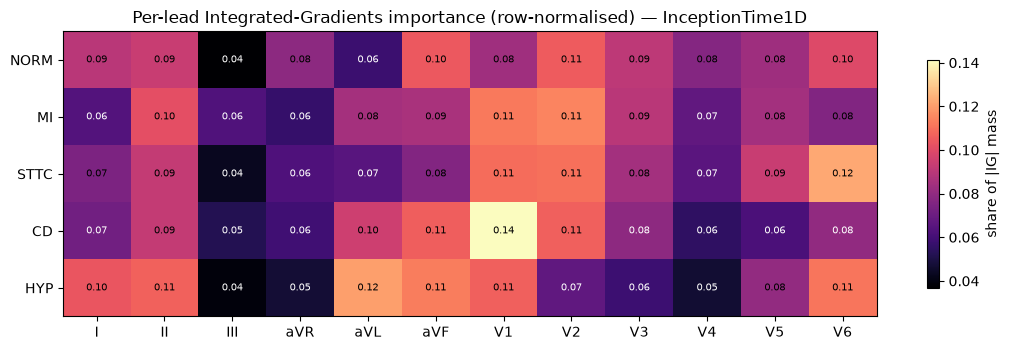

In [6]:
rng = np.random.default_rng(SEED)
I_lead = np.zeros((NUM_CLASSES, NUM_LEADS))
per_class_n = {}
for k, sc in enumerate(SUPERCLASSES):
    pos_idx = np.where(y_test[:, k] == 1)[0]
    take = rng.choice(pos_idx, size=min(N_ATTR_SUBSAMPLE, len(pos_idx)), replace=False)
    per_class_n[sc] = len(take)
    acc = np.zeros(NUM_LEADS)
    for j in take:
        ig = integrated_gradients(X_test[j], k)          # (12,1000)
        acc += np.abs(ig).mean(axis=1)                   # mean over time -> (12,)
    I_lead[k] = acc / len(take)

I_norm = I_lead / I_lead.sum(axis=1, keepdims=True)      # row-normalise for readability
print('[IG] per-class subsample sizes:', per_class_n)

CLINICAL = {  # Atwa et al. 2025 §4.6 — leads clinically emphasised per superclass
    'NORM': '(diffuse / no single lead)',
    'MI'  : 'V2, II, V3, V4',
    'STTC': 'V4, V5, aVR',
    'CD'  : 'V1, V2, V3',
    'HYP' : 'V5, V6, V1',
}
print(f'\n{"class":<6s}{"top-3 leads (IG)":<26s}{"clinical expectation (Atwa 2025)":<34s}')
for k, sc in enumerate(SUPERCLASSES):
    top3 = [LEAD_NAMES[i] for i in np.argsort(I_norm[k])[::-1][:3]]
    print(f'{sc:<6s}{", ".join(top3):<26s}{CLINICAL[sc]:<34s}')

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(I_norm, aspect='auto', cmap='magma')
ax.set_xticks(range(NUM_LEADS)); ax.set_xticklabels(LEAD_NAMES)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(SUPERCLASSES)
for k in range(NUM_CLASSES):
    for l in range(NUM_LEADS):
        ax.text(l, k, f'{I_norm[k, l]:.02f}', ha='center', va='center',
                color='white' if I_norm[k, l] < I_norm[k].max() * 0.6 else 'black', fontsize=7)
ax.set_title('Per-lead Integrated-Gradients importance (row-normalised) — InceptionTime1D')
fig.colorbar(im, ax=ax, shrink=0.8, label='share of |IG| mass')
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '06xai_per_lead_importance.png', dpi=200); plt.show()

### Module 3b — baseline-sensitivity variant

IG attributions depend on the baseline `x'`. We recompute the per-lead ranking with a **per-lead-mean
baseline** (each lead set to its own TEST-set mean trace) and report Spearman rank agreement with the
zero-baseline ranking — a stable ranking across baselines is more trustworthy.

In [7]:
from scipy.stats import spearmanr
lead_mean = X_test.mean(axis=0)                          # (12,1000)
I_lead_mb = np.zeros((NUM_CLASSES, NUM_LEADS))
for k, sc in enumerate(SUPERCLASSES):
    pos_idx = np.where(y_test[:, k] == 1)[0]
    take = rng.choice(pos_idx, size=min(120, len(pos_idx)), replace=False)
    acc = np.zeros(NUM_LEADS)
    for j in take:
        ig = integrated_gradients(X_test[j], k, baseline=lead_mean)
        acc += np.abs(ig).mean(axis=1)
    I_lead_mb[k] = acc / len(take)

print(f'{"class":<6s}{"Spearman rho (zero vs mean baseline lead-ranking)":<50s}')
for k, sc in enumerate(SUPERCLASSES):
    rho = spearmanr(I_lead[k], I_lead_mb[k]).statistic
    print(f'{sc:<6s}{rho:>8.3f}')

class Spearman rho (zero vs mean baseline lead-ranking) 
NORM     0.979
MI       0.986
STTC     0.972
CD       0.993
HYP      0.909


## Module 4 — Time-domain attribution maps (Strodthoff et al. 2020, Fig 8 style)

For one **high-confidence, correctly-classified** TEST record per class, overlay the Integrated-Gradients
attribution as a colour wash on each lead's waveform, and show the Grad-CAM-1D temporal saliency as a
strip beneath. This is the qualitative "does the relevance land on real ECG morphology (QRS complex,
ST segment, T wave)?" check.

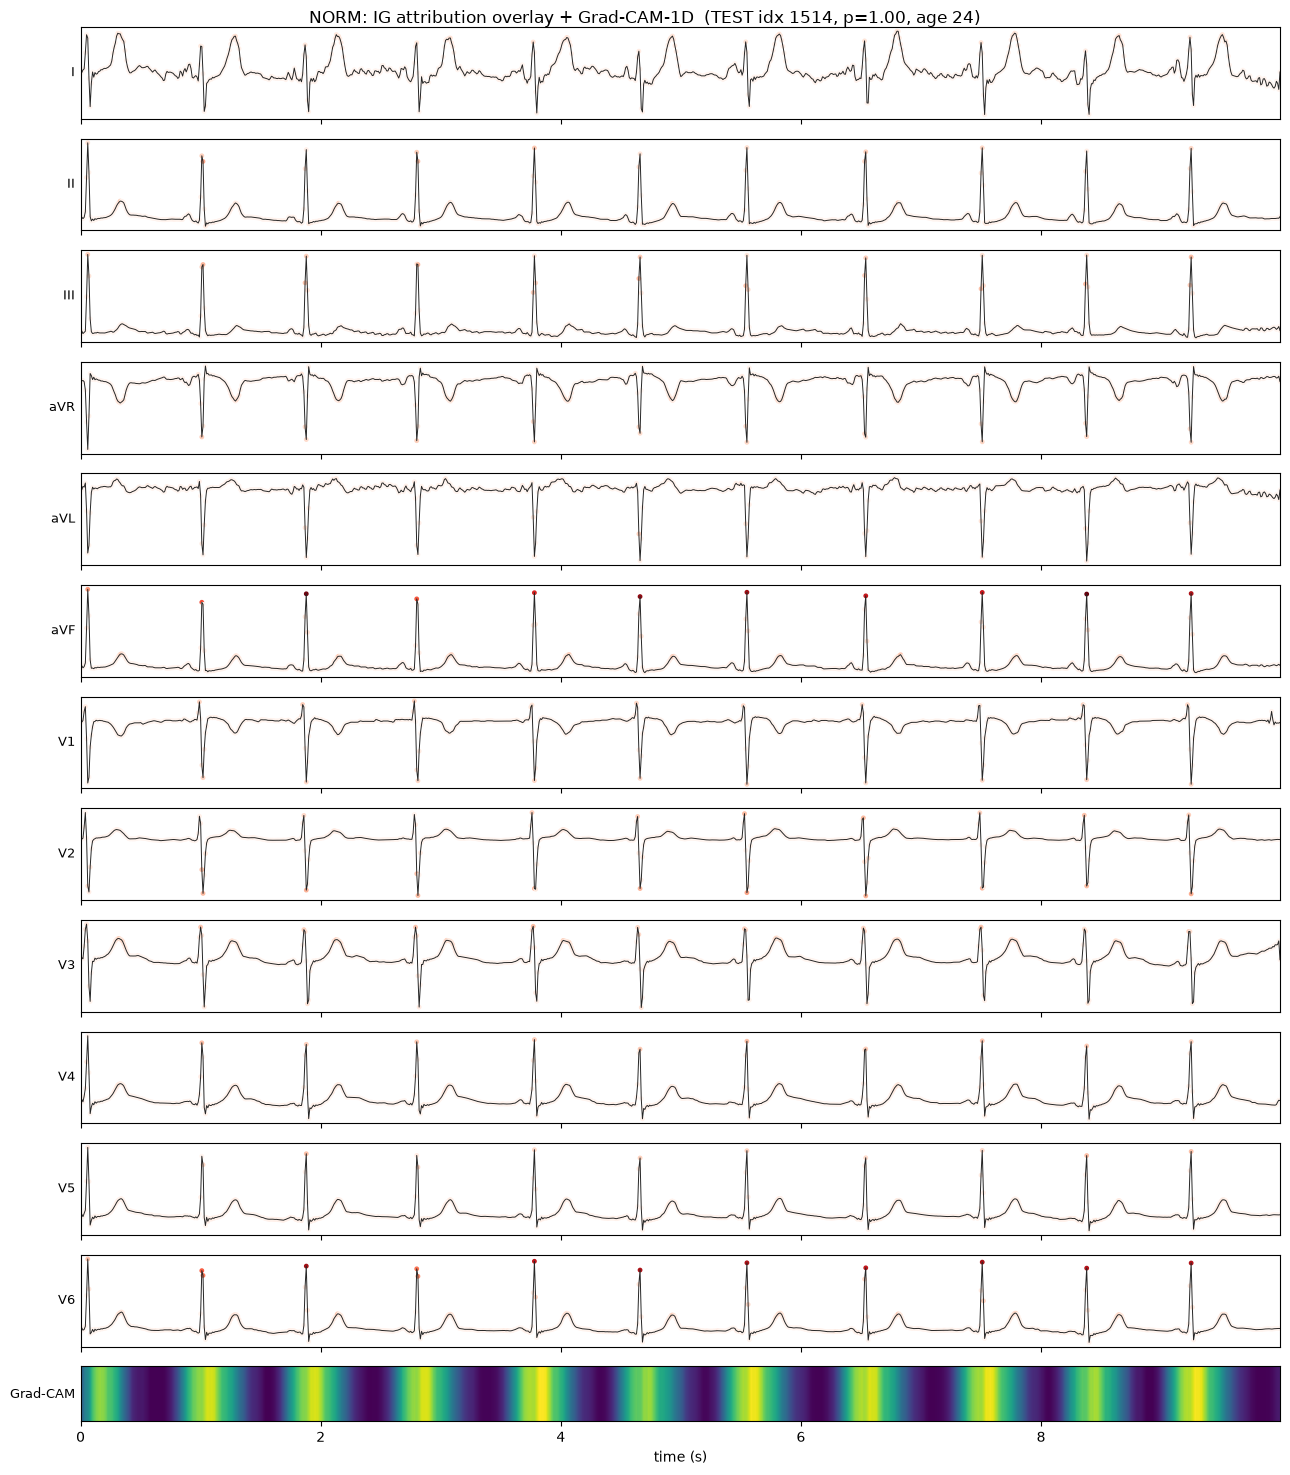

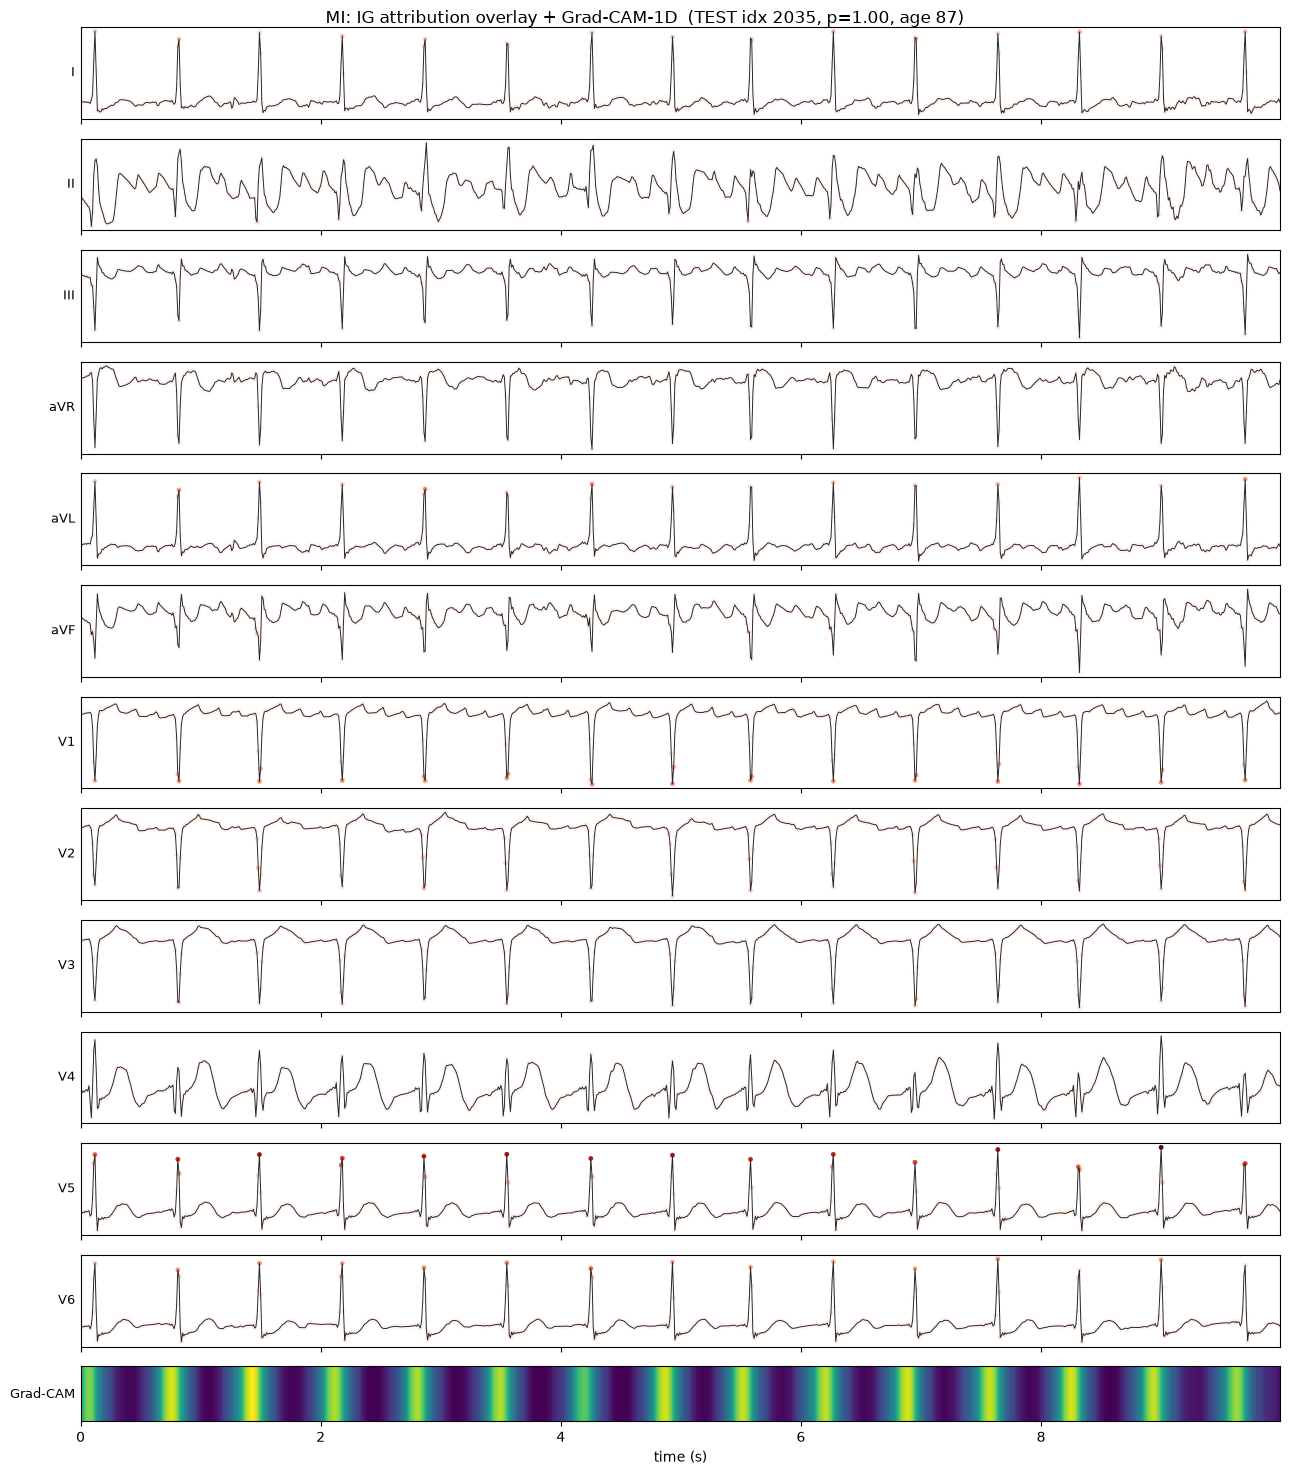

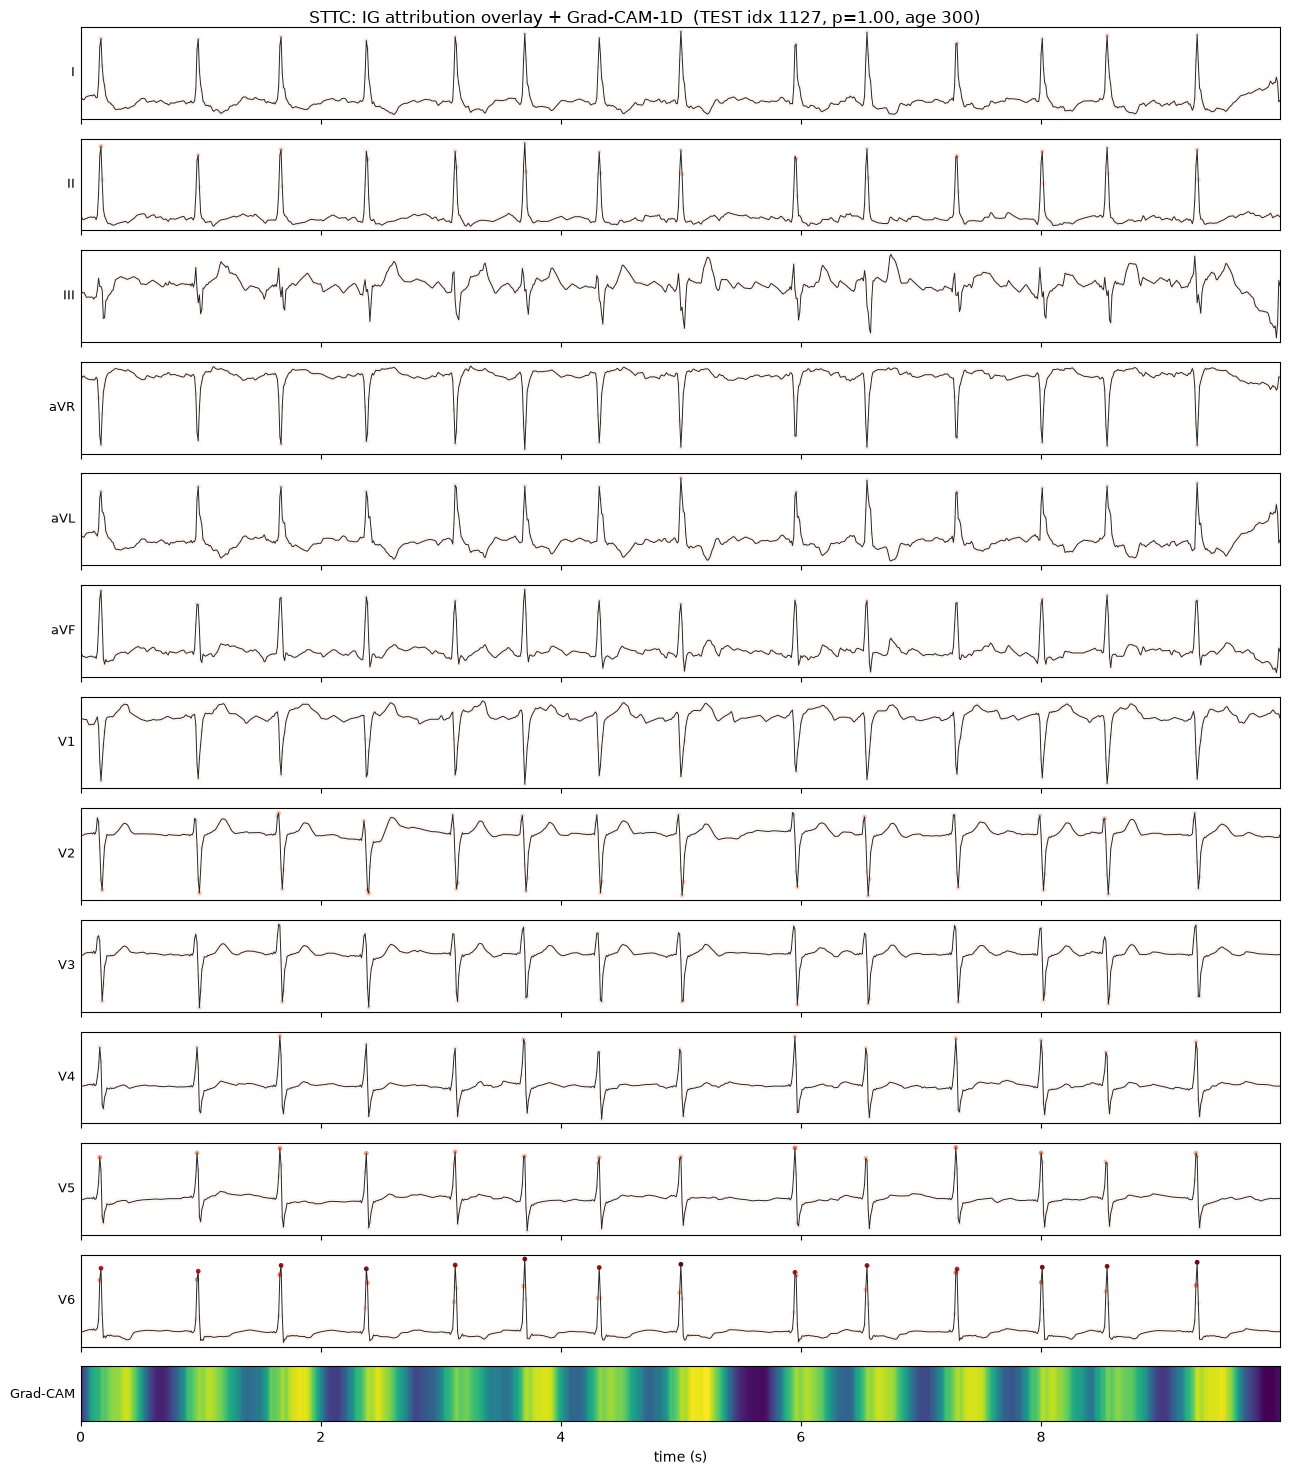

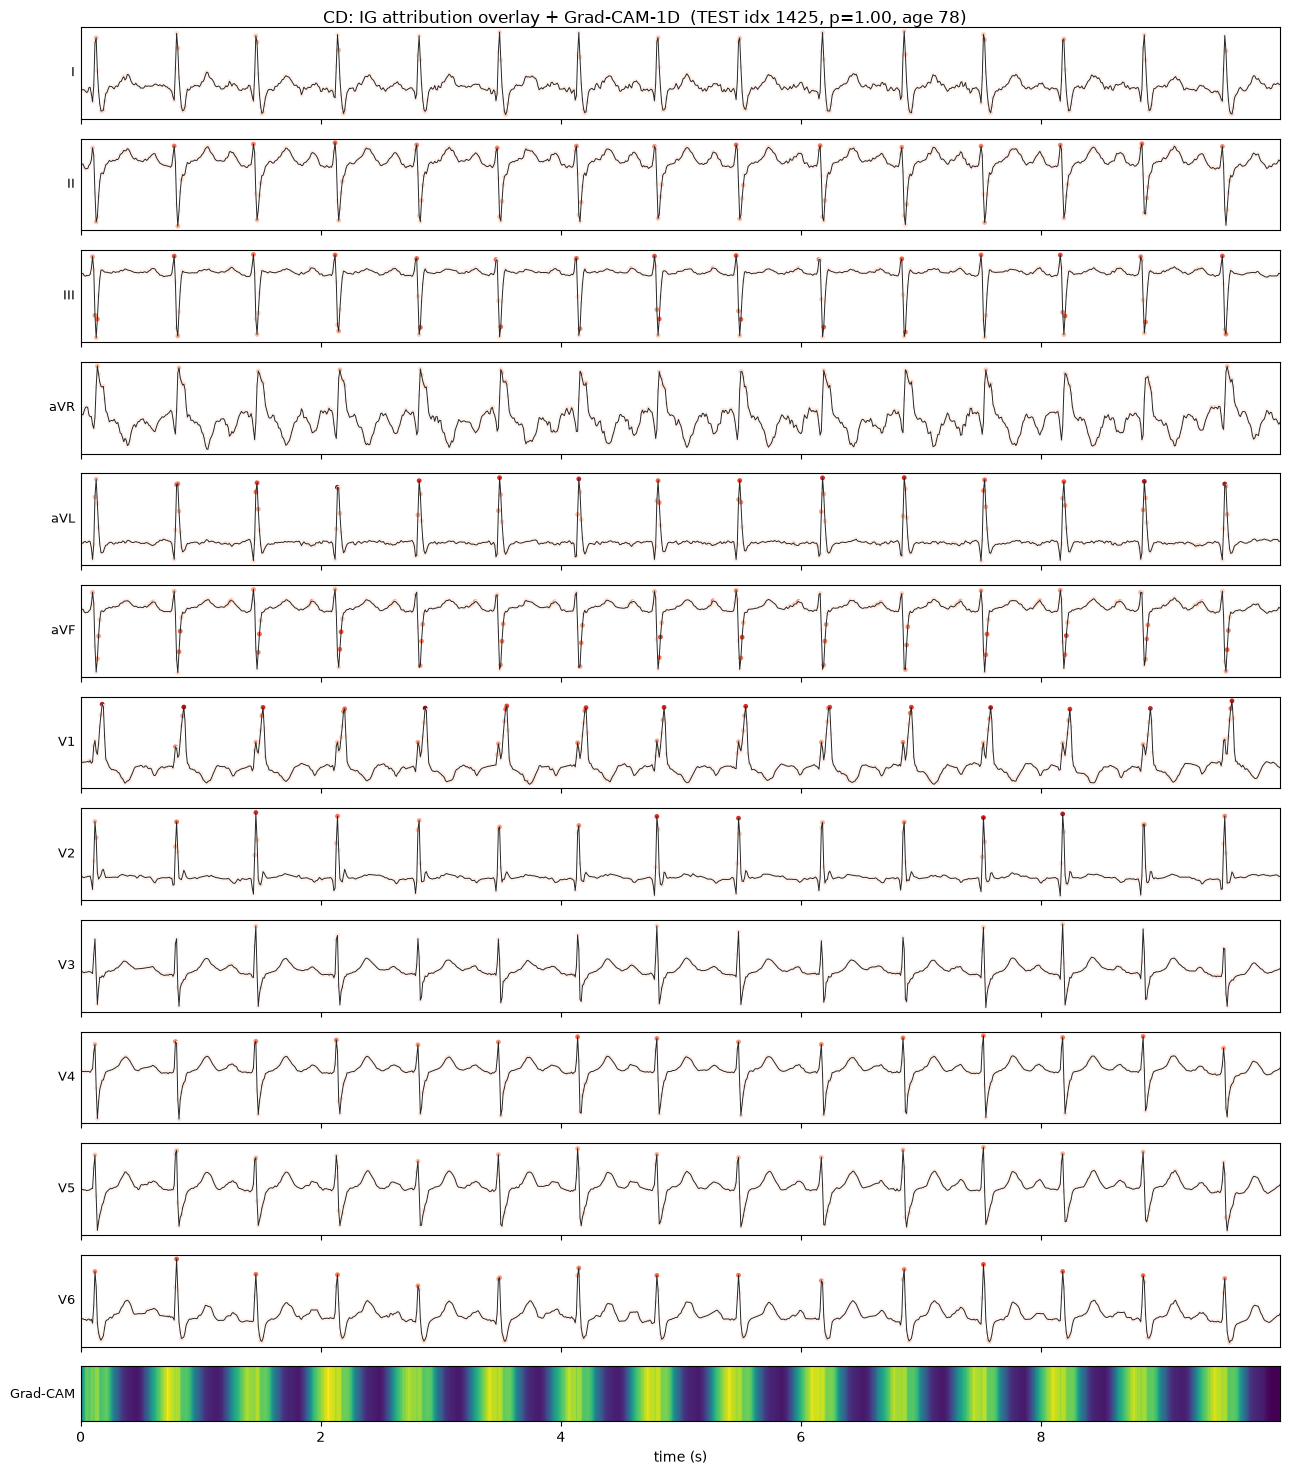

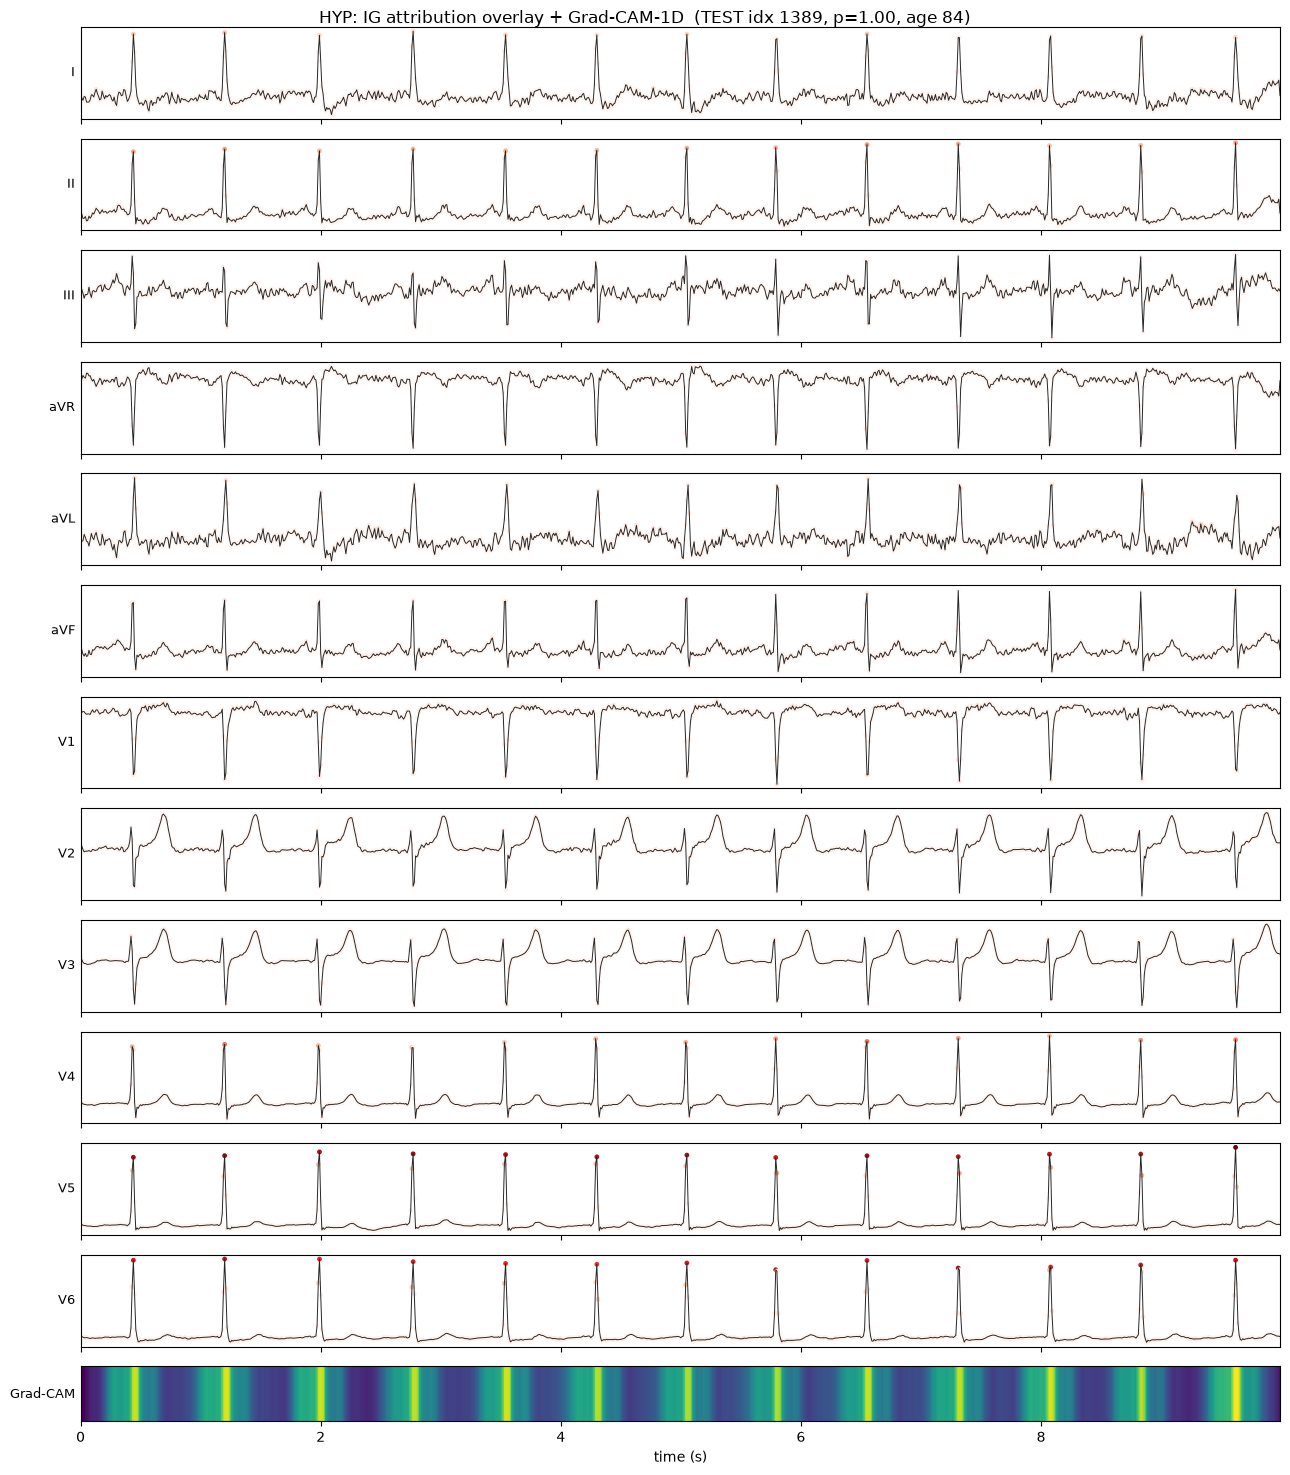

In [8]:

def pick_example(k):
    pos = np.where(y_test[:, k] == 1)[0]
    return pos[np.argmax(P_test[pos, k])]                # most confident true positive

t = np.arange(SIG_LEN) / FS
for k, sc in enumerate(SUPERCLASSES):
    j = pick_example(k)
    ig  = integrated_gradients(X_test[j], k)             # (12,1000)
    cam = grad_cam_1d(X_test[j], k)                      # (1000,)
    sig = X_test[j]
    a = np.abs(ig); a = a / (a.max() + 1e-9)

    fig, axes = plt.subplots(NUM_LEADS + 1, 1, figsize=(13, 15), sharex=True,
                             gridspec_kw={'height_ratios': [1]*NUM_LEADS + [0.6]})
    for l in range(NUM_LEADS):
        ax = axes[l]
        ax.plot(t, sig[l], color='0.15', lw=0.7)
        ax.scatter(t, sig[l], c=a[l], cmap='Reds', s=6, vmin=0, vmax=1)
        ax.set_ylabel(LEAD_NAMES[l], rotation=0, ha='right', va='center', fontsize=9)
        ax.set_yticks([])
    axes[-1].imshow(cam[None], aspect='auto', cmap='viridis', extent=[t[0], t[-1], 0, 1])
    axes[-1].set_yticks([]); axes[-1].set_ylabel('Grad-CAM', rotation=0, ha='right', va='center', fontsize=9)
    axes[-1].set_xlabel('time (s)')
    fig.suptitle(f'{sc}: IG attribution overlay + Grad-CAM-1D  '
                 f'(TEST idx {j}, p={P_test[j, k]:.2f}, age {age_test[j]:.0f})', fontsize=12)
    fig.tight_layout()
    fig.savefig(OUTPUTS_VAL / f'06xai_map_{sc}.png', dpi=170); plt.show()

## Module 5 — Faithfulness: lead-ablation test  (the check Atwa did not run)

If per-lead IG importance is *faithful*, then **removing the top-`k` important leads must degrade the
class AUC more than removing `k` random leads**. "Removing" a lead = replacing it with its TEST-set mean
trace (a deletion-metric occlusion). We sweep `k = 1..6` and report the AUC drop for both.

class   k    drop: top-k IG leads  drop: random k leads (mean of 5)
NORM    1                  0.0040                            0.0105
NORM    2                  0.0203                            0.0181
NORM    3                  0.0396                            0.0347
NORM    4                  0.0836                            0.0392
NORM    5                  0.0672                            0.0715
NORM    6                  0.1049                            0.0883
MI      1                  0.0293                            0.0105
MI      2                  0.0601                            0.0294
MI      3                  0.1039                            0.0373
MI      4                  0.1614                            0.0667
MI      5                  0.2101                            0.0846
MI      6                  0.2078                            0.2111
STTC    1                  0.0140                            0.0058
STTC    2                  0.0304               

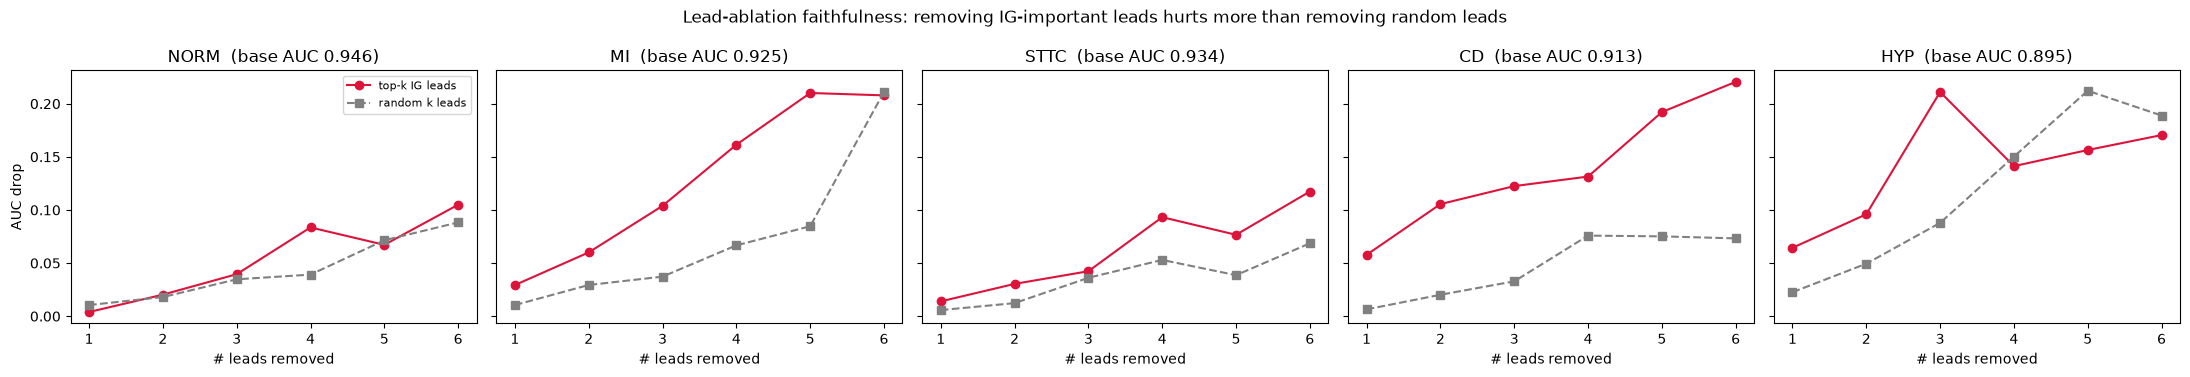


[CONCENTRATION] share of |IG| mass in top-3 leads:
  NORM   0.31   (0.25 = uniform over 12 leads)
  MI     0.33   (0.25 = uniform over 12 leads)
  STTC   0.34   (0.25 = uniform over 12 leads)
  CD     0.35   (0.25 = uniform over 12 leads)
  HYP    0.34   (0.25 = uniform over 12 leads)


In [9]:
def ablate_auc(k_class, leads_to_zero):
    Xa = X_test.copy()
    Xa[:, leads_to_zero, :] = lead_mean[leads_to_zero, :]
    p = predict_proba(Xa)[:, k_class]
    return roc_auc_score(y_test[:, k_class], p)

ks = [1, 2, 3, 4, 5, 6]
base_auc = {k: roc_auc_score(y_test[:, k], P_test[:, k]) for k in range(NUM_CLASSES)}
rng2 = np.random.default_rng(SEED)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 3.8), sharey=True)
print(f'{"class":<6s}{"k":>3s}{"drop: top-k IG leads":>24s}{"drop: random k leads (mean of 5)":>34s}')
for kc, sc in enumerate(SUPERCLASSES):
    order = np.argsort(I_norm[kc])[::-1]
    d_top, d_rand = [], []
    for k in ks:
        a_top = ablate_auc(kc, list(order[:k]))
        rand_drops = []
        for _ in range(5):
            rl = rng2.choice(NUM_LEADS, size=k, replace=False)
            rand_drops.append(base_auc[kc] - ablate_auc(kc, list(rl)))
        d_top.append(base_auc[kc] - a_top)
        d_rand.append(float(np.mean(rand_drops)))
        print(f'{sc:<6s}{k:>3d}{d_top[-1]:>24.4f}{d_rand[-1]:>34.4f}')
    ax = axes[kc]
    ax.plot(ks, d_top, 'o-', color='crimson', label='top-k IG leads')
    ax.plot(ks, d_rand, 's--', color='0.5', label='random k leads')
    ax.set_title(f'{sc}  (base AUC {base_auc[kc]:.3f})'); ax.set_xlabel('# leads removed')
    if kc == 0: ax.set_ylabel('AUC drop'); ax.legend(fontsize=8)
fig.suptitle('Lead-ablation faithfulness: removing IG-important leads hurts more than removing random leads', fontsize=12)
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '06xai_faithfulness_ablation.png', dpi=200); plt.show()

# concentration: share of |IG| mass in the top-3 leads
print('\n[CONCENTRATION] share of |IG| mass in top-3 leads:')
for kc, sc in enumerate(SUPERCLASSES):
    top3_mass = np.sort(I_norm[kc])[::-1][:3].sum()
    print(f'  {sc:<5s}  {top3_mass:.2f}   (0.25 = uniform over 12 leads)')

## Module 6 — Sanity check: model-randomisation test (Adebayo et al. 2018)

Re-initialise the network with random weights and recompute per-lead IG importance. A faithful
attribution method should give a ranking that is **uncorrelated** with the trained model's — if the two
match, the "explanation" is really just reacting to input structure (e.g. an edge detector), not to
anything the model learned. We report Spearman `rho` between trained and random-model lead rankings.

In [10]:
trained_state = {k: v.clone() for k, v in model.state_dict().items()}
rand_model = InceptionTime1D(NUM_CLASSES).to(DEVICE)     # fresh random init
def _swap(m):
    global model
    model = m; model.eval()

_swap(rand_model)
I_rand = np.zeros((NUM_CLASSES, NUM_LEADS))
for k in range(NUM_CLASSES):
    pos_idx = np.where(y_test[:, k] == 1)[0]
    take = rng.choice(pos_idx, size=min(120, len(pos_idx)), replace=False)
    acc = np.zeros(NUM_LEADS)
    for j in take:
        acc += np.abs(integrated_gradients(X_test[j], k)).mean(axis=1)
    I_rand[k] = acc / len(take)

# restore trained model
_trained = InceptionTime1D(NUM_CLASSES).to(DEVICE); _trained.load_state_dict(trained_state); _trained.eval()
_swap(_trained)

print(f'{"class":<6s}{"Spearman rho (trained vs random-init lead ranking)":<52s}{"verdict":<10s}')
for k, sc in enumerate(SUPERCLASSES):
    rho = spearmanr(I_norm[k], I_rand[k] / I_rand[k].sum()).statistic
    print(f'{sc:<6s}{rho:>8.3f}{"":<8s}{"ok (low)" if abs(rho) < 0.5 else "CHECK (high)"}')

class Spearman rho (trained vs random-init lead ranking)  verdict   
NORM     0.476        ok (low)
MI       0.406        ok (low)
STTC     0.580        CHECK (high)
CD       0.189        ok (low)
HYP     -0.182        ok (low)


## Module 7 — Age-Stratified Explanation Consistency (elderly, low- vs high-confidence)

**Why this module exists.** The project's "triangulation" around age has two legs already measured —
accuracy (NB02/NB03: exact-match collapses from 78% under-40 to 43% in 80+) and uncertainty/calibration
(NB05: the 80+ band is both the least accurate *and* the worst-calibrated, and Module 9 there shows
achieving the sensitivity target for elderly patients needs a larger conformal prediction set). The third
leg — **does the explanation itself get less trustworthy for the elderly cases the model is least sure
about?** — is still open. If per-lead attribution is unstable exactly where the model is uncertain, that
is a further, independent reason to defer those cases to a cardiologist rather than trust the "why".

**Method.**
1. **Elderly** = `age ≥ 65` on `TEST` (matches NB01's `elderly_65_plus` flag; combines the `65-80` and
   `80+` bands used throughout NB02/03/05, n = 1,048 / 2,198).
2. **Confidence** = the NB05 Module 9 ensemble-disagreement score `u_disag` (std of the 3 heterogeneous
   NB02/NB03 members' probabilities, averaged over classes) — reloaded here verbatim from the same
   checkpoints. We do **not** reuse NB05's saved numbers; we recompute `u_disag` on `TEST` in this
   notebook so the split is self-contained and reproducible from this file alone.
3. Split the elderly group at its **median** `u_disag` into *low-confidence elderly* (above median —
   more member disagreement) and *high-confidence elderly* (below median), n ≈ 524 each.
4. **Explanation-consistency check**, extending Module 3b's baseline-sensitivity idea to a
   *sample*-sensitivity check: for each class, randomly split each confidence subgroup's true-positive
   records into two halves, compute the per-lead Integrated-Gradients importance ranking (Module 3's
   `I_l` formula) independently on each half, and report the **Spearman ρ between the two halves**. A
   *faithful, stable* explanation should agree with itself across independent samples of the same
   population (high ρ); if ρ is systematically lower for the low-confidence elderly subgroup, that is
   direct evidence the explanation degrades exactly where the model itself is unsure — closing the third
   leg of the triangulation.

**Honest scope note.** This is a **single** random split per subgroup per class (matching Module 3b's own
single-shot style, not a bootstrap) — the ρ values below carry sampling noise from that one split, not a
confidence interval. The *direction* of any low-vs-high gap is the intended read, not the exact ρ value.

In [11]:
# ---- Reload DualBranchECGNet + ResNet1D101 (verbatim from NB02/NB03/NB05) purely to recompute the
# ---- NB05 Module 9 ensemble-disagreement uncertainty score u_disag on TEST ----
class DualBranchECGNet(nn.Module):
    def __init__(self, num_classes=5, in_channels=12):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(in_channels, 32, 3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(32, 64, 3, padding=1),  nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(128, 256, 3, padding=1),nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(256, 512, 3, padding=1),nn.BatchNorm1d(512), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.demo_branch = nn.Sequential(
            nn.Linear(2, 100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(100, 64),nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 16), nn.BatchNorm1d(16),  nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(528, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes))
    def forward(self, ecg, demo):
        return self.classifier(torch.cat([self.ecg_branch(ecg).squeeze(-1), self.demo_branch(demo)], dim=1))

class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                                      nn.BatchNorm1d(out_channels))
        self.act = nn.ReLU()
    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))

class ResNet1D101(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
        def stage(i, o, n, stride=2):
            return nn.Sequential(ResBlock1D(i, o, stride), *[ResBlock1D(o, o) for _ in range(n - 1)])
        self.stage1 = stage(64, 64, 8, stride=1)
        self.stage2 = stage(64, 128, 8, stride=2)
        self.stage3 = stage(128, 256, 8, stride=2)
        self.stage4 = stage(256, 512, 8, stride=2)
        self.pool = nn.AdaptiveAvgPool1d(1); self.drop = nn.Dropout(drop); self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        return self.fc(self.drop(self.pool(x).squeeze(-1)))

CKPT_DB  = OUTPUTS_DIR / 'ensemble_DualBranchECGNet_best.pth'
CKPT_RES = OUTPUTS_DIR / 'ensemble_ResNet1D101_best.pth'
assert CKPT_DB.exists() and CKPT_RES.exists(), 'Missing NB02 ensemble checkpoints — run 02_3Model_Heterogeneous_Ensemble.ipynb first.'

df_meta      = pd.read_csv(DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv')
df_train_m   = df_meta[df_meta['split'] == 'TRAIN']
df_test_m    = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
age_mean, age_std = df_train_m['age'].mean(), df_train_m['age'].std()
demo_test = np.column_stack([
    ((df_test_m['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values,
    (df_test_m['sex'] == 1).values.astype(np.float32),
]).astype(np.float32)

model_db  = DualBranchECGNet(NUM_CLASSES).to(DEVICE)
model_db.load_state_dict(torch.load(CKPT_DB, map_location=DEVICE, weights_only=True)); model_db.eval()
model_res = ResNet1D101(NUM_CLASSES).to(DEVICE)
model_res.load_state_dict(torch.load(CKPT_RES, map_location=DEVICE, weights_only=True)); model_res.eval()

@torch.no_grad()
def predict_proba_db(X, demo, bs=64):
    out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(DEVICE); db = torch.from_numpy(demo[i:i+bs]).to(DEVICE)
        out.append(torch.sigmoid(model_db(xb, db)).cpu().numpy())
    return np.vstack(out)

@torch.no_grad()
def predict_proba_plain(m, X, bs=64):
    out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(DEVICE)
        out.append(torch.sigmoid(m(xb)).cpu().numpy())
    return np.vstack(out)

P_test_db  = predict_proba_db(X_test, demo_test)
P_test_res = predict_proba_plain(model_res, X_test)

# P_test (InceptionTime1D) already computed in Module 1b, and `model` there is restored trained state after Module 6
P_stack = np.stack([P_test_db, P_test, P_test_res])   # order matches NB05: DualBranch, InceptionTime, ResNet101
u_disag = P_stack.std(0).mean(1)                       # per-record disagreement, NB05 Module 9 definition verbatim

print(f'[CHECK] DualBranchECGNet TEST macro-AUC {np.mean([roc_auc_score(y_test[:,k], P_test_db[:,k]) for k in range(NUM_CLASSES)]):.4f}')
print(f'[CHECK] ResNet1D101      TEST macro-AUC {np.mean([roc_auc_score(y_test[:,k], P_test_res[:,k]) for k in range(NUM_CLASSES)]):.4f}')
print(f'[CHECK] mean ensemble disagreement u_disag = {u_disag.mean():.4f}  (NB05 reported mean 0.046 correct-case / 0.076 incorrect-case)')

[CHECK] DualBranchECGNet TEST macro-AUC 0.8994
[CHECK] ResNet1D101      TEST macro-AUC 0.9178
[CHECK] mean ensemble disagreement u_disag = 0.0596  (NB05 reported mean 0.046 correct-case / 0.076 incorrect-case)


In [12]:
elderly = age_test >= 65    # matches NB01's elderly_65_plus flag (65-80 + 80+ age bands)
med_u = np.median(u_disag[elderly])
low_conf_elderly  = elderly & (u_disag >= med_u)   # more member disagreement -> LESS confident
high_conf_elderly = elderly & (u_disag <  med_u)   # less disagreement -> MORE confident

print(f'[SPLIT] elderly (65+): n={int(elderly.sum())} / {len(age_test)}')
print(f'[SPLIT] low-confidence elderly  (u_disag >= median {med_u:.4f}): n={int(low_conf_elderly.sum())}  mean u_disag={u_disag[low_conf_elderly].mean():.4f}')
print(f'[SPLIT] high-confidence elderly (u_disag <  median {med_u:.4f}): n={int(high_conf_elderly.sum())}  mean u_disag={u_disag[high_conf_elderly].mean():.4f}')
for name, m in [('low-confidence elderly', low_conf_elderly), ('high-confidence elderly', high_conf_elderly)]:
    print(f'  {name}: pos/class = {dict(zip(SUPERCLASSES, y_test[m].sum(0).astype(int)))}')

[SPLIT] elderly (65+): n=1048 / 2198
[SPLIT] low-confidence elderly  (u_disag >= median 0.0632): n=524  mean u_disag=0.1007
[SPLIT] high-confidence elderly (u_disag <  median 0.0632): n=524  mean u_disag=0.0416
  low-confidence elderly: pos/class = {'NORM': np.int64(91), 'MI': np.int64(194), 'STTC': np.int64(187), 'CD': np.int64(153), 'HYP': np.int64(96)}
  high-confidence elderly: pos/class = {'NORM': np.int64(148), 'MI': np.int64(185), 'STTC': np.int64(163), 'CD': np.int64(166), 'HYP': np.int64(88)}


In [13]:
MAX_PER_HALF = 80

def split_half_lead_ranking(mask, k, half_rng):
    pos_idx = np.where(mask & (y_test[:, k] == 1))[0].copy()
    half_rng.shuffle(pos_idx)
    mid = len(pos_idx) // 2
    halves = [pos_idx[:mid], pos_idx[mid:]]
    rankings = []
    for h in halves:
        take = h[:MAX_PER_HALF]
        acc = np.zeros(NUM_LEADS)
        for j in take:
            acc += np.abs(integrated_gradients(X_test[j], k)).mean(axis=1)
        rankings.append(acc / max(len(take), 1))
    return rankings[0], rankings[1], len(halves[0][:MAX_PER_HALF]), len(halves[1][:MAX_PER_HALF])

stability_rng = np.random.default_rng(SEED)
stability_rows = []
for subgroup_name, mask in [('low-confidence elderly', low_conf_elderly), ('high-confidence elderly', high_conf_elderly)]:
    for k, sc in enumerate(SUPERCLASSES):
        ra, rb, na, nb = split_half_lead_ranking(mask, k, stability_rng)
        rho = spearmanr(ra, rb).statistic
        stability_rows.append((subgroup_name, sc, na, nb, rho))

print(f'{"subgroup":<26s}{"class":<7s}{"n(half A)":>10s}{"n(half B)":>10s}{"Spearman rho":>14s}')
for r in stability_rows:
    print(f'{r[0]:<26s}{r[1]:<7s}{r[2]:>10d}{r[3]:>10d}{r[4]:>14.3f}')

macro_rho = {name: float(np.mean([r[4] for r in stability_rows if r[0] == name]))
             for name in ['low-confidence elderly', 'high-confidence elderly']}
print(f'\n[HEADLINE] macro-average split-half lead-ranking Spearman rho:')
for name, v in macro_rho.items():
    print(f'  {name:<26s}  rho = {v:.3f}')
delta = macro_rho['low-confidence elderly'] - macro_rho['high-confidence elderly']
print(f"\n[HEADLINE] low-confidence elderly rho is {'LOWER' if delta < 0 else 'NOT lower'} than high-confidence elderly rho (delta={delta:+.3f})"
      f" -> explanation consistency {'DOES' if delta < 0 else 'does NOT clearly'} degrade for low-confidence elderly cases.")

subgroup                  class   n(half A) n(half B)  Spearman rho
low-confidence elderly    NORM           45        46         0.909
low-confidence elderly    MI             80        80         0.986
low-confidence elderly    STTC           80        80         0.993
low-confidence elderly    CD             76        77         0.965
low-confidence elderly    HYP            48        48         0.923
high-confidence elderly   NORM           74        74         0.951
high-confidence elderly   MI             80        80         0.986
high-confidence elderly   STTC           80        80         0.979
high-confidence elderly   CD             80        80         1.000
high-confidence elderly   HYP            44        44         0.986

[HEADLINE] macro-average split-half lead-ranking Spearman rho:
  low-confidence elderly      rho = 0.955
  high-confidence elderly     rho = 0.980

[HEADLINE] low-confidence elderly rho is LOWER than high-confidence elderly rho (delta=-0.025) -> expla

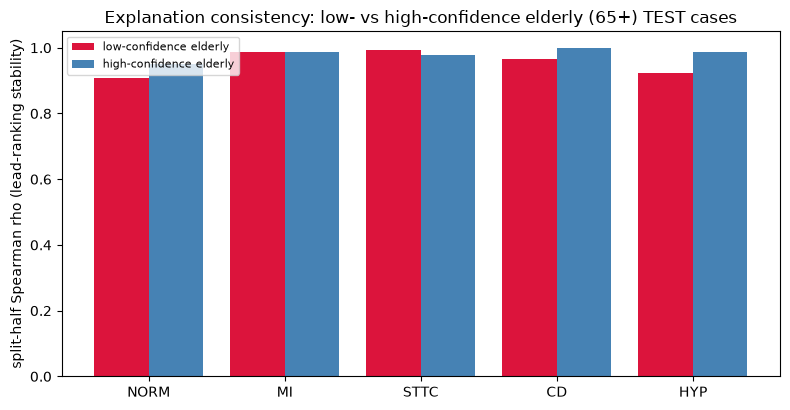

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
classes_x = np.arange(NUM_CLASSES)
rho_low  = [r[4] for r in stability_rows if r[0] == 'low-confidence elderly']
rho_high = [r[4] for r in stability_rows if r[0] == 'high-confidence elderly']
ax.bar(classes_x - 0.2, rho_low,  0.4, label='low-confidence elderly',  color='crimson')
ax.bar(classes_x + 0.2, rho_high, 0.4, label='high-confidence elderly', color='steelblue')
ax.set_xticks(classes_x); ax.set_xticklabels(SUPERCLASSES)
ax.set_ylabel('split-half Spearman rho (lead-ranking stability)')
ax.axhline(0, color='k', lw=0.6)
ax.set_title('Explanation consistency: low- vs high-confidence elderly (65+) TEST cases')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '06xai_age_confidence_explanation_stability.png', dpi=200); plt.show()

## Module 8 — Conclusion

**What this establishes for the "explainable" claim**

| Question | Where | Reading |
|---|---|---|
| Which leads drive each superclass? | Module 3 heatmap + top-3 table | compare to Atwa §4.6 clinical expectation |
| Is the lead ranking robust to the IG baseline? | Module 3b | Spearman `rho` (zero vs mean baseline) |
| Does relevance fall on real ECG morphology? | Module 4 overlays + Grad-CAM strip | qualitative, Strodthoff Fig 8 style |
| Is the attribution *faithful* (not just plausible)? | Module 5 | top-k IG ablation drop vs random-lead drop; top-3 mass concentration |
| Is the explanation model-dependent (not an artefact)? | Module 6 | trained-vs-random Spearman `rho` should be low |
| Does explanation consistency degrade for low-confidence elderly cases (Section E, the third triangulation leg)? | Module 7 | split-half Spearman `rho` of the per-class lead ranking, low- vs high-confidence elderly (65+) — see printed macro-rho above. |

**How every choice is anchored**
- `I_l` aggregation: Atwa et al. 2025 §3.6 formula, verbatim.
- Integrated Gradients as the SHAP substitute: Sundararajan et al. 2017 (completeness + implementation invariance); `shap`/`captum` unavailable in this env.
- Signal-overlay maps + temporal Grad-CAM: Strodthoff et al. 2020 §IV-D / Fig 8.
- Faithfulness + randomisation tests: the validation Atwa's single unchecked SHAP chart lacked (Petsiuk et al. 2018; Adebayo et al. 2018).
- Age-stratified explanation consistency: extends Module 3b's baseline-sensitivity idea to a sample-split stability check, using NB05 Module 9's ensemble-disagreement uncertainty score to define the low-/high-confidence elderly split — closes the third ('does the explanation itself hold up') leg of the accuracy / uncertainty / explanation triangulation around age.

**Honest limitations** — IG ≠ SHAP; no LRP-ε (library); single TEST fold, subsampled `I_l`, no bootstrap CI
(`Whats_Needed_Next.md` Tier 3.1); explains the single InceptionTime1D, not the full ensemble or the
DualBranch demographic pathway. Module 7's split-half comparison uses a **single** random split per subgroup per class (not bootstrapped), so its rho values carry sampling noise from that one split — the direction of the low-vs-high gap is the intended read, not the exact number.

**Ties back:** with NB05 (calibration + uncertainty) and this notebook (attribution + faithfulness), all
three clauses of the project title — *age-stratified*, *explainable*, *uncertainty-calibrated* — now have
measured results rather than only aspirational text.